In [2]:
!pip install scipy
!pip install seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np 
import seaborn as sns
import statistics as stat
from scipy import stats
import matplotlib.pyplot as plot

In [6]:
sd = pd.read_csv('student_dataset.csv')
sd.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Final_Exam_Score
0,23.5,84.2,Low,Low,Yes,7.4,50.3,Medium,Yes,1,54.3
1,19.7,63.6,Medium,High,Yes,6.7,83.1,Low,Yes,2,59.4
2,24.4,98.4,Medium,Medium,Yes,8.0,63.5,Medium,Yes,0,63.8
3,29.6,88.6,Medium,High,Yes,6.3,57.5,Medium,Yes,2,61.0
4,19.1,91.5,High,Medium,Yes,6.2,66.0,Medium,Yes,2,60.7


In [7]:
sd.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6607 non-null   float64
 1   Attendance                  6607 non-null   float64
 2   Parental_Involvement        6607 non-null   str    
 3   Access_to_Resources         6607 non-null   str    
 4   Extracurricular_Activities  6607 non-null   str    
 5   Sleep_Hours                 6607 non-null   float64
 6   Previous_Scores             6607 non-null   float64
 7   Motivation_Level            6607 non-null   str    
 8   Internet_Access             6607 non-null   str    
 9   Tutoring_Sessions           6607 non-null   int64  
 10  Final_Exam_Score            6607 non-null   float64
dtypes: float64(5), int64(1), str(5)
memory usage: 567.9 KB


In [8]:
sd.shape

(6607, 11)

In [9]:
sd.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Final_Exam_Score
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,20.472726,79.979068,7.185273,74.716059,1.488119,60.400333
std,5.988729,11.547717,1.290241,14.451962,1.216175,8.739400
min,1.100000,60.000000,4.000000,50.000000,0.000000,29.700000
25%,16.500000,70.000000,6.300000,62.100000,1.000000,54.300000
50%,20.500000,79.800000,7.200000,74.600000,1.000000,60.400000
75%,24.500000,90.200000,8.100000,87.400000,2.000000,66.600000
max,44.000000,100.000000,10.000000,100.000000,8.000000,95.200000


In [10]:
sd['Final_Exam_Score'].mode()

0    60.0
Name: Final_Exam_Score, dtype: float64

<Axes: xlabel='Final_Exam_Score', ylabel='Count'>

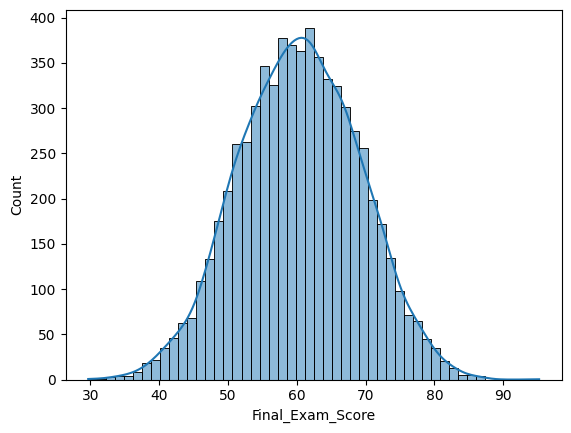

In [11]:
sns.histplot(sd['Final_Exam_Score'], kde=True)

In [12]:
sd[['Hours_Studied', 'Final_Exam_Score']].corr()

,Hours_Studied,Final_Exam_Score
Hours_Studied,1.00000,0.40985
Final_Exam_Score,0.40985,1.00000


In [13]:
sd[['Attendance', 'Final_Exam_Score']].corr()

,Attendance,Final_Exam_Score
Attendance,1.000000,0.266152
Final_Exam_Score,0.266152,1.000000


In [14]:
sd.groupby('Parental_Involvement')['Final_Exam_Score'].mean()

Parental_Involvement
High      60.251728
Low       60.499372
Medium    60.449747
Name: Final_Exam_Score, dtype: float64

In [15]:
sd.groupby('Access_to_Resources')['Final_Exam_Score'].mean()

Access_to_Resources
High      62.258110
Low       58.304300
Medium    60.103016
Name: Final_Exam_Score, dtype: float64

In [16]:
sd.groupby('Internet_Access')['Final_Exam_Score'].mean()

Internet_Access
No     60.288911
Yes    60.409732
Name: Final_Exam_Score, dtype: float64

In [17]:
improved = sd[sd['Final_Exam_Score'] > sd['Previous_Scores']+5]
improved.shape

(216, 11)

In [18]:
percentage = (improved.shape[0]/sd.shape[0])*100
print (f"{percentage}% of students increased their score from previous test")

3.2692598758892086% of students increased their score from previous test


In [19]:
not_improved = sd[sd['Final_Exam_Score'] < sd['Previous_Scores'] + 5]
not_improved.shape

(6386, 11)

In [21]:
col = ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Sleep_Hours', 'Final_Exam_Score']
comparison = pd.DataFrame({ "Improved": improved[col].mean(), "Not_Improved": not_improved[col].mean()})
comparison

,Improved,Not_Improved
Hours_Studied,26.127315,20.279001
Attendance,86.744444,79.747244
Previous_Scores,55.624074,75.376104
Sleep_Hours,7.101852,7.188428
Final_Exam_Score,64.026852,60.276824


In [22]:
sd['Tutoring_Sessions'].max()

np.int64(8)

In [23]:
sd.groupby(pd.qcut(sd['Hours_Studied'], 4))['Final_Exam_Score'].mean()

Hours_Studied
(1.0990000000000002, 16.5]    55.870006
(16.5, 20.5]                  59.208523
(20.5, 24.5]                  61.747691
(24.5, 44.0]                  64.896560
Name: Final_Exam_Score, dtype: float64

In [24]:
low_perf = sd[sd['Final_Exam_Score'] < sd['Final_Exam_Score'].quantile(0.25)]
low_perf.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Final_Exam_Score
count,1646.000000,1646.000000,1646.000000,1646.000000,1646.000000,1646.000000
mean,17.407594,76.104678,7.206622,62.382564,1.213852,49.212272
std,5.603634,11.197763,1.271588,9.933749,1.098970,4.085478
min,1.100000,60.000000,4.000000,50.000000,0.000000,29.700000
25%,13.625000,66.600000,6.300000,54.700000,0.000000,47.100000
50%,17.400000,74.450000,7.200000,60.200000,1.000000,50.200000
75%,21.000000,84.600000,8.100000,67.575000,2.000000,52.400000
max,35.900000,100.000000,10.000000,99.600000,7.000000,54.200000


In [25]:
sd['Extracurricular_Activities'].value_counts()

Extracurricular_Activities
Yes    3988
No     2619
Name: count, dtype: int64

In [26]:
sd['Improved'] = sd['Final_Exam_Score'] >= sd['Previous_Scores'] + 5

In [27]:
sd.groupby('Extracurricular_Activities')['Improved'].mean() * 100

Extracurricular_Activities
No     3.780069
Yes    3.059178
Name: Improved, dtype: float64

In [28]:
pd.crosstab(sd['Extracurricular_Activities'], sd['Improved'])

Improved,False,True
Extracurricular_Activities,,
No,2520,99
Yes,3866,122


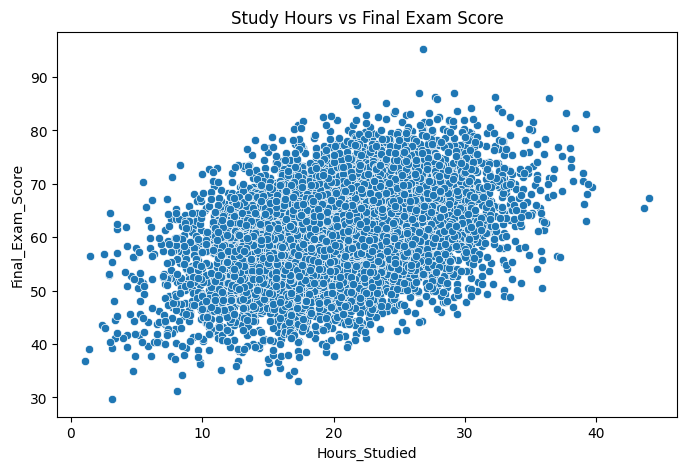

In [29]:
plot.figure(figsize=(8,5))
sns.scatterplot(x=sd['Hours_Studied'], y=sd['Final_Exam_Score'])
plot.title("Study Hours vs Final Exam Score")
plot.show()

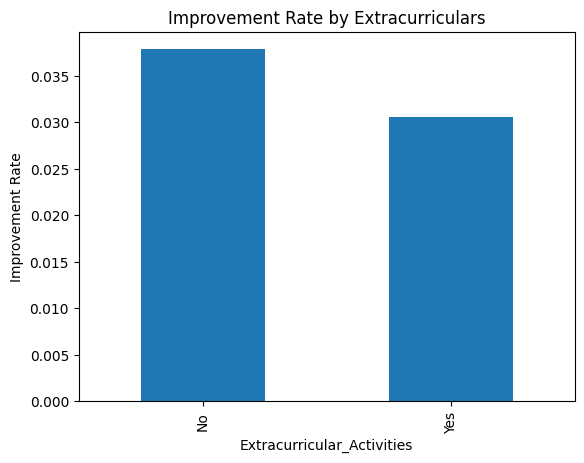

In [30]:
sd.groupby('Extracurricular_Activities')['Improved'].mean().plot(kind='bar')
plot.title("Improvement Rate by Extracurriculars")
plot.ylabel("Improvement Rate")
plot.show()

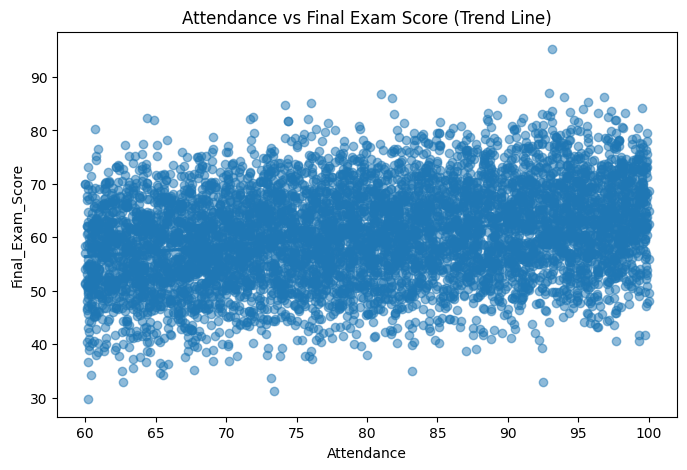

In [31]:

plot.figure(figsize=(8,5))
sns.regplot(x=sd['Attendance'], y=sd['Final_Exam_Score'], scatter_kws={'alpha':0.5})

plot.title("Attendance vs Final Exam Score (Trend Line)")
plot.show()

In [33]:
high = sd[sd['Motivation_Level'] == 'High']['Hours_Studied']
medium = sd[sd['Motivation_Level'] == 'Medium']['Hours_Studied']
low = sd[sd['Motivation_Level'] == 'Low']['Hours_Studied']
stats.f_oneway(high, medium, low)

F_onewayResult(statistic=np.float64(0.5557501043066048), pvalue=np.float64(0.5736686344811659))

In [34]:
sd.groupby('Motivation_Level')['Hours_Studied'].mean()

Motivation_Level
High      20.614521
Low       20.390822
Medium    20.462374
Name: Hours_Studied, dtype: float64

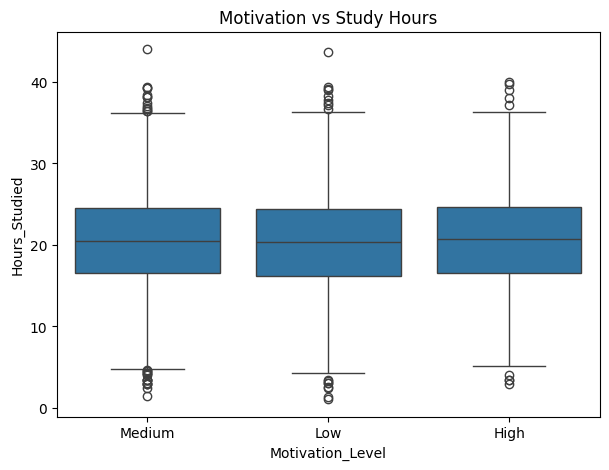

In [37]:
plot.figure(figsize=(7,5))
sns.boxplot(x='Motivation_Level', y='Hours_Studied', data=sd)
plot.title("Motivation vs Study Hours")
plot.show()